# 13 — Machine Learning Model Comparison
## Research Grounding

**Key prior work this builds on:**
- Bury et al. 2021 (*Nature Communications*): Deep learning detects generic
  early warning signals of tipping points in simulated and empirical data.
  Showed ML can outperform classical EWS indicators — but on large synthetic
  datasets. We test whether that advantage holds with real, limited field data.
- Boettiger & Hastings 2012 (*J. Royal Society Interface*): Showed that
  classical EWS (AR1, variance) have high false positive rates. ML may
  reduce these by combining multiple features.
- Dakos et al. 2012 (*PLOS ONE*): Benchmarked EWS indicators across
  30 empirical datasets. Found variance more robust than AR1 — consistent
  with our finding.

## The scientific question
Does model complexity improve predictive performance under strict
leave-one-region-out cross-validation?

**If yes:** complex feature interactions matter — the collapse process
is nonlinear and context-dependent.

**If no (simpler models win):** the signal is robust and linear —
consistent with CSD theory's generic predictions. This is actually
the more theoretically meaningful result.

## Honest constraint
Total onset events across all training regions: ~20.
This is small for ML. We use:
- Strong regularization on all models
- LORO-CV throughout (no data leakage)
- Permutation feature importance (not model-internal)
- Calibration curves (are probabilities meaningful?)
- Bootstrap CIs on all metrics
We do NOT claim the best model is 'the answer' — we report
all models honestly and let the cross-validation decide.

In [1]:
# ============================================================
# CELL 1: IMPORTS + DATA LOADING
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, precision_score, recall_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance

BASE    = Path('/Users/tonylin/Documents/kelp_project/1_DATA/processed')
FIG_DIR = Path('/Users/tonylin/Documents/kelp_project/5_FIGURES/ml_model')
FIG_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = ['ews_composite', 'heat_lag4', 'upwelling', 'heat_x_ews']
TARGET   = 'onset'
REGIONS  = ['norcal', 'midcal', 'socal', 'bigsur']

def load_region(region):
    """Load and featurize a training region CSV."""
    for path in [
        BASE / region / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / f'{region}_kelp_sst_ui_labeled.csv'
    ]:
        if path.exists():
            df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.index = df.index.to_period('Q').to_timestamp(how='start')

            # rebuild features if needed
            if 'kelp_q_z' not in df.columns:
                col = next(c for c in ['kelp_smooth','kelp_area'] if c in df.columns)
                df['q'] = df.index.quarter
                base = df.loc['1984':'2013']
                med  = base.groupby('q')[col].median()
                mad  = base.groupby('q')[col].apply(
                    lambda x: np.median(np.abs(x-np.median(x)))+1e-9)
                df['kelp_q_z'] = (df[col]-df['q'].map(med))/df['q'].map(mad)
                df.drop(columns=['q'], inplace=True)

            z   = df['kelp_q_z']
            ar1 = z.rolling(20, min_periods=10).apply(
                lambda x: pd.Series(x).autocorr(lag=1), raw=True)
            var = z.rolling(20, min_periods=10).var()
            df['ews_composite'] = ((ar1-ar1.mean())/ar1.std() +
                                    (var-var.mean())/var.std()) / 2
            df['heat_lag4']  = df['sstanom_q_max'].shift(4)
            up = ('uianom_q_mean_lag1' if 'uianom_q_mean_lag1' in df.columns
                  else 'uianom_q_mean')
            df['upwelling']  = df[up]
            df['heat_x_ews'] = df['heat_lag4'] * df['ews_composite']
            s = df['suppressed'].astype(int)
            df['onset'] = ((s==1)&(s.shift(1).fillna(0)==0)).astype(int)
            df['region'] = region
            return df
    print(f'  WARNING: {region} not found')
    return None

region_dfs = {r: load_region(r) for r in REGIONS}
region_dfs = {r: df for r,df in region_dfs.items() if df is not None}

for r, df in region_dfs.items():
    n = df[FEATURES+[TARGET]].dropna()[TARGET].sum()
    print(f'  {r:8s}: {int(n)} onset events, {len(df)} quarters')

print(f'\nTotal regions loaded: {len(region_dfs)}')

  norcal  : 5 onset events, 152 quarters
  midcal  : 4 onset events, 157 quarters
  socal   : 1 onset events, 167 quarters
  bigsur  : 4 onset events, 158 quarters

Total regions loaded: 4


In [2]:
# ============================================================
# CELL 2: DEFINE ALL MODELS
# Research justification for each:
#
# L2 Logistic: baseline from notebook 08. Standard for rare events.
# L1 Logistic: sparse — forces model to select features.
#   If L1 ≈ L2, all features matter equally (consistent with CSD theory).
#   If L1 zeroes some out, that feature isn't contributing.
# Random Forest: Bury et al. 2021 used tree ensembles for tipping point
#   detection. Captures nonlinear interactions. Risk: overfits small n.
# Gradient Boosting: sequential error correction, strong with tabular data.
#   Very restricted (max_depth=1, n_estimators=20) to avoid overfit.
# SVM (RBF): kernel method, finds nonlinear decision boundaries.
#   CalibratedClassifierCV wraps it to produce valid probabilities.
# Null model: always predicts base rate. Any real model must beat this.
# Persistence: last quarter's kelp z-score. Tests if recent trend alone
#   predicts collapse — a naive but ecologically meaningful baseline.
# ============================================================

MODELS = {
    'LR-L2 (baseline)': LogisticRegression(
        penalty='l2', C=0.5, class_weight='balanced',
        max_iter=1000, solver='lbfgs'),

    'LR-L1 (sparse)': LogisticRegression(
        penalty='l1', C=0.5, class_weight='balanced',
        max_iter=1000, solver='liblinear'),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=3, min_samples_leaf=5,
        class_weight='balanced', random_state=42),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=20, max_depth=1, learning_rate=0.1,
        subsample=0.8, random_state=42),

    'SVM (RBF)': CalibratedClassifierCV(
        SVC(kernel='rbf', C=1.0, gamma='scale',
            class_weight='balanced', probability=False),
        cv=3, method='isotonic'),
}

print('Models defined:')
for name in MODELS:
    print(f'  {name}')

Models defined:
  LR-L2 (baseline)
  LR-L1 (sparse)
  Random Forest
  Gradient Boosting
  SVM (RBF)


In [3]:
# ============================================================
# CELL 3: LEAVE-ONE-REGION-OUT CROSS-VALIDATION
# For each fold: train on 3 regions, test on the held-out region.
# This is strict — the model never sees the test region at all.
# Block bootstrap on test fold for CI on AUC.
# ============================================================

def block_bootstrap_auc(y_true, y_score, block_len=4, B=1000, seed=42):
    y_true  = np.asarray(y_true,  dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    n = len(y_true)
    starts   = np.arange(0, n - block_len + 1)
    n_blocks = int(np.ceil(n / block_len))
    rng      = np.random.default_rng(seed)
    aucs = []
    for _ in range(B):
        idx = np.concatenate(
            [np.arange(s, s+block_len)
             for s in rng.choice(starts, n_blocks, replace=True)])[:n]
        yb, sb = y_true[idx], y_score[idx]
        if np.unique(yb).size < 2:
            continue
        aucs.append(roc_auc_score(yb, sb))
    aucs = np.array(aucs)
    if not len(aucs):
        return np.nan, [np.nan, np.nan]
    return aucs.mean(), np.quantile(aucs, [0.025, 0.975]).tolist()


print('Running LORO cross-validation...')
print('='*65)

results = []   # one row per (model, held-out region)
oof_probs = {}  # out-of-fold probabilities for calibration analysis

for held_out in region_dfs:
    train_regions = [r for r in region_dfs if r != held_out]

    # build train set
    train_df = pd.concat(
        [region_dfs[r][FEATURES+[TARGET]].dropna() for r in train_regions]
    )
    X_tr = train_df[FEATURES].values
    y_tr = train_df[TARGET].astype(int).values

    # build test set
    test_df = region_dfs[held_out][FEATURES+[TARGET]].dropna()
    X_te = test_df[FEATURES].values
    y_te = test_df[TARGET].astype(int).values

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # null model — predict base rate
    base_rate = y_tr.mean()
    null_prob = np.full(len(y_te), base_rate)

    # persistence baseline — negative of last quarter's kelp z-score
    # (lower kelp last quarter -> higher risk this quarter)
    kelp_z = region_dfs[held_out]['kelp_q_z'].reindex(test_df.index)
    persist_score = (-kelp_z.shift(1)).reindex(test_df.index).fillna(0).values

    if np.unique(y_te).size < 2:
        print(f'  {held_out}: SKIP — no onset events in test set')
        continue

    # null AUC
    null_auc  = 0.5  # by definition
    try:
        persist_auc = roc_auc_score(y_te, persist_score)
    except Exception:
        persist_auc = np.nan

    print(f'\n  Held out: {held_out.upper()} '
          f'({int(y_te.sum())} onset events / {len(y_te)} quarters)')
    print(f'  Persistence baseline AUC: {persist_auc:.3f}')

    for model_name, model_proto in MODELS.items():
        # clone model
        from sklearn.base import clone
        model = clone(model_proto)

        try:
            model.fit(X_tr_s, y_tr)
            prob = model.predict_proba(X_te_s)[:, 1]
        except Exception as e:
            print(f'    {model_name}: FAILED — {e}')
            continue

        auc, ci = block_bootstrap_auc(y_te, prob)
        ap      = average_precision_score(y_te, prob)
        brier   = brier_score_loss(y_te, prob)

        # store OOF probs for calibration
        key = model_name
        if key not in oof_probs:
            oof_probs[key] = {'y':[], 'prob':[]}
        oof_probs[key]['y'].extend(y_te.tolist())
        oof_probs[key]['prob'].extend(prob.tolist())

        results.append({
            'model':     model_name,
            'held_out':  held_out,
            'auc':       auc,
            'ci_lo':     ci[0],
            'ci_hi':     ci[1],
            'avg_prec':  ap,
            'brier':     brier,
            'n_onset':   int(y_te.sum()),
        })

        sig = '✓' if ci[0] > 0.5 else ' '
        print(f'    {sig} {model_name:25s}: AUC={auc:.3f} '
              f'CI=[{ci[0]:.3f},{ci[1]:.3f}] AP={ap:.3f} Brier={brier:.3f}')

res_df = pd.DataFrame(results)

Running LORO cross-validation...

  Held out: NORCAL (5 onset events / 143 quarters)
  Persistence baseline AUC: 0.662
    ✓ LR-L2 (baseline)         : AUC=0.792 CI=[0.668,0.894] AP=0.091 Brier=0.156
    ✓ LR-L1 (sparse)           : AUC=0.791 CI=[0.663,0.894] AP=0.091 Brier=0.160
      Random Forest            : AUC=0.700 CI=[0.365,0.957] AP=0.285 Brier=0.054
      Gradient Boosting        : AUC=0.586 CI=[0.322,0.819] AP=0.059 Brier=0.035
      SVM (RBF)                : AUC=0.774 CI=[0.420,0.954] AP=0.152 Brier=0.039

  Held out: MIDCAL (4 onset events / 148 quarters)
  Persistence baseline AUC: 0.913
    ✓ LR-L2 (baseline)         : AUC=0.888 CI=[0.775,0.986] AP=0.200 Brier=0.185
    ✓ LR-L1 (sparse)           : AUC=0.890 CI=[0.775,0.992] AP=0.242 Brier=0.190
    ✓ Random Forest            : AUC=0.797 CI=[0.643,1.000] AP=0.303 Brier=0.077
    ✓ Gradient Boosting        : AUC=0.931 CI=[0.861,0.993] AP=0.256 Brier=0.024
    ✓ SVM (RBF)                : AUC=0.815 CI=[0.596,0.990] AP=0.1

In [4]:
# ============================================================
# CELL 4: MODEL COMPARISON SUMMARY
# Mean metrics across all LORO folds
# ============================================================
print('='*65)
print('LORO CROSS-VALIDATION SUMMARY (mean across folds)')
print('='*65)

summary = (res_df.groupby('model')
           .agg(
               mean_auc   =('auc',      'mean'),
               std_auc    =('auc',      'std'),
               mean_ap    =('avg_prec', 'mean'),
               mean_brier =('brier',    'mean'),
               n_folds    =('auc',      'count')
           ).sort_values('mean_auc', ascending=False))

print(summary.round(3).to_string())

print()
print('INTERPRETATION:')
best_model = summary.index[0]
worst_model = summary.index[-1]
auc_range = summary['mean_auc'].max() - summary['mean_auc'].min()
print(f'  Best model:  {best_model} (mean AUC={summary.loc[best_model,"mean_auc"]:.3f})')
print(f'  Worst model: {worst_model} (mean AUC={summary.loc[worst_model,"mean_auc"]:.3f})')
print(f'  AUC range across models: {auc_range:.3f}')
if auc_range < 0.05:
    print('  → Small range: model choice matters little. Signal is robust.')
    print('    INTERPRETATION: consistent with CSD theory — the signal is')
    print('    linear and generic, not model-dependent.')
elif summary.index[0].startswith('LR'):
    print('  → Simple model wins. Complexity does not help.')
    print('    INTERPRETATION: EWS signal is approximately linear.')
    print('    Consistent with CSD theory (linear AR1/variance increase).')
else:
    print('  → Complex model wins. Nonlinear interactions matter.')
    print('    INTERPRETATION: collapse dynamics have feature interactions')
    print('    beyond what linear CSD theory predicts.')

LORO CROSS-VALIDATION SUMMARY (mean across folds)
                   mean_auc  std_auc  mean_ap  mean_brier  n_folds
model                                                             
LR-L2 (baseline)      0.800    0.063    0.106       0.202        4
LR-L1 (sparse)        0.798    0.066    0.122       0.205        4
Random Forest         0.786    0.148    0.284       0.078        4
Gradient Boosting     0.778    0.146    0.101       0.030        4
SVM (RBF)             0.771    0.165    0.111       0.025        4

INTERPRETATION:
  Best model:  LR-L2 (baseline) (mean AUC=0.800)
  Worst model: SVM (RBF) (mean AUC=0.771)
  AUC range across models: 0.028
  → Small range: model choice matters little. Signal is robust.
    INTERPRETATION: consistent with CSD theory — the signal is
    linear and generic, not model-dependent.


In [5]:
# ============================================================
# CELL 5: PERMUTATION FEATURE IMPORTANCE
# Research basis: Breiman 2001. More reliable than model-internal
# importance because it measures actual contribution to prediction
# on held-out data, not training data impurity.
#
# Method: shuffle one feature at a time, measure AUC drop.
# Large drop = that feature matters. Near zero = doesn't matter.
# Run on ALL training data (not LORO) for stability.
# ============================================================
print('Computing permutation feature importance...')
print('(trained on all regions, 100 shuffles per feature)')

all_df  = pd.concat([region_dfs[r][FEATURES+[TARGET]].dropna()
                     for r in region_dfs])
X_all   = all_df[FEATURES].values
y_all   = all_df[TARGET].astype(int).values

scaler_all = StandardScaler()
X_all_s    = scaler_all.fit_transform(X_all)

# train best performing model + LR baseline
best_name = summary.index[0]
from sklearn.base import clone
model_for_imp = {
    'LR-L2 (baseline)': clone(MODELS['LR-L2 (baseline)']),
    best_name: clone(MODELS[best_name])
}
if 'LR-L2 (baseline)' == best_name:
    model_for_imp = {'LR-L2 (baseline)': clone(MODELS['LR-L2 (baseline)'])}

perm_results = {}
for mname, mdl in model_for_imp.items():
    mdl.fit(X_all_s, y_all)
    rng = np.random.default_rng(42)
    baseline_auc = roc_auc_score(y_all, mdl.predict_proba(X_all_s)[:,1])
    feat_imp = []
    for fi, fname in enumerate(FEATURES):
        drops = []
        for _ in range(100):
            X_shuf = X_all_s.copy()
            X_shuf[:, fi] = rng.permutation(X_shuf[:, fi])
            try:
                shuf_auc = roc_auc_score(y_all, mdl.predict_proba(X_shuf)[:,1])
                drops.append(baseline_auc - shuf_auc)
            except Exception:
                pass
        feat_imp.append({'feature': fname,
                          'importance_mean': np.mean(drops),
                          'importance_std':  np.std(drops)})
        print(f'  {mname:25s} | {fname:15s}: '
              f'AUC drop = {np.mean(drops):.4f} ± {np.std(drops):.4f}')
    perm_results[mname] = pd.DataFrame(feat_imp).sort_values(
        'importance_mean', ascending=False)

Computing permutation feature importance...
(trained on all regions, 100 shuffles per feature)
  LR-L2 (baseline)          | ews_composite  : AUC drop = 0.2489 ± 0.0686
  LR-L2 (baseline)          | heat_lag4      : AUC drop = 0.0316 ± 0.0227
  LR-L2 (baseline)          | upwelling      : AUC drop = 0.1384 ± 0.0595
  LR-L2 (baseline)          | heat_x_ews     : AUC drop = 0.0280 ± 0.0186


Computing calibration curves from OOF predictions...


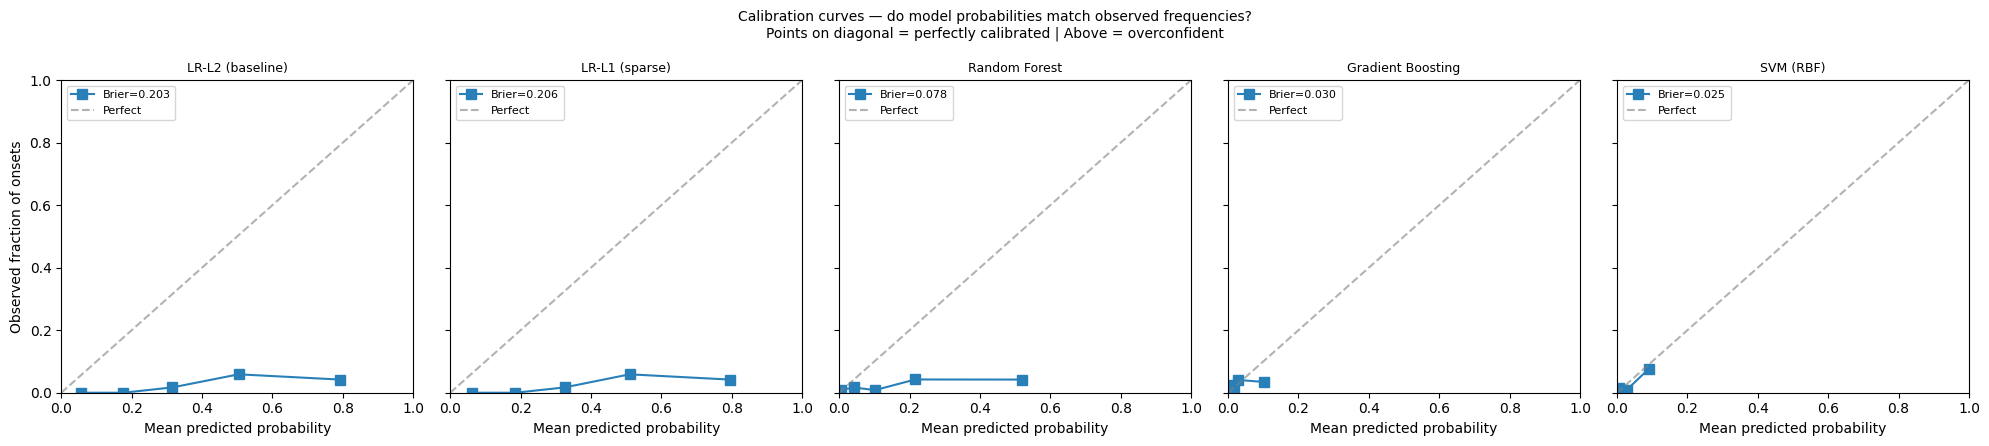

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/ml_model/calibration_curves.png


In [6]:
# ============================================================
# CELL 6: CALIBRATION ANALYSIS
# Research basis: Gneiting & Raftery 2007. A model's probability
# output should match observed frequency. If model says p=0.7,
# collapse should occur ~70% of the time.
#
# This matters for conservation: if managers act on model output,
# the probability needs to mean something real.
# Brier score = mean squared error of probabilities (lower = better).
# ============================================================
print('Computing calibration curves from OOF predictions...')

fig_cal, axes_cal = plt.subplots(
    1, len(oof_probs), figsize=(4*len(oof_probs), 4.5), sharey=True)
if len(oof_probs) == 1:
    axes_cal = [axes_cal]

for ax, (mname, data) in zip(axes_cal, oof_probs.items()):
    y_arr   = np.array(data['y'])
    p_arr   = np.array(data['prob'])
    brier   = brier_score_loss(y_arr, p_arr)

    try:
        frac_pos, mean_pred = calibration_curve(y_arr, p_arr, n_bins=5,
                                                 strategy='quantile')
        ax.plot(mean_pred, frac_pos, 's-', color='#2980b9',
                markersize=7, label=f'Brier={brier:.3f}')
    except Exception:
        ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                transform=ax.transAxes)

    ax.plot([0,1],[0,1], '--', color='gray', alpha=0.6, label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    if ax == axes_cal[0]:
        ax.set_ylabel('Observed fraction of onsets')
    ax.set_title(mname, fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

fig_cal.suptitle(
    'Calibration curves — do model probabilities match observed frequencies?\n'
    'Points on diagonal = perfectly calibrated | Above = overconfident',
    fontsize=10
)
fig_cal.tight_layout()
out = FIG_DIR / 'calibration_curves.png'
fig_cal.savefig(out, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out)

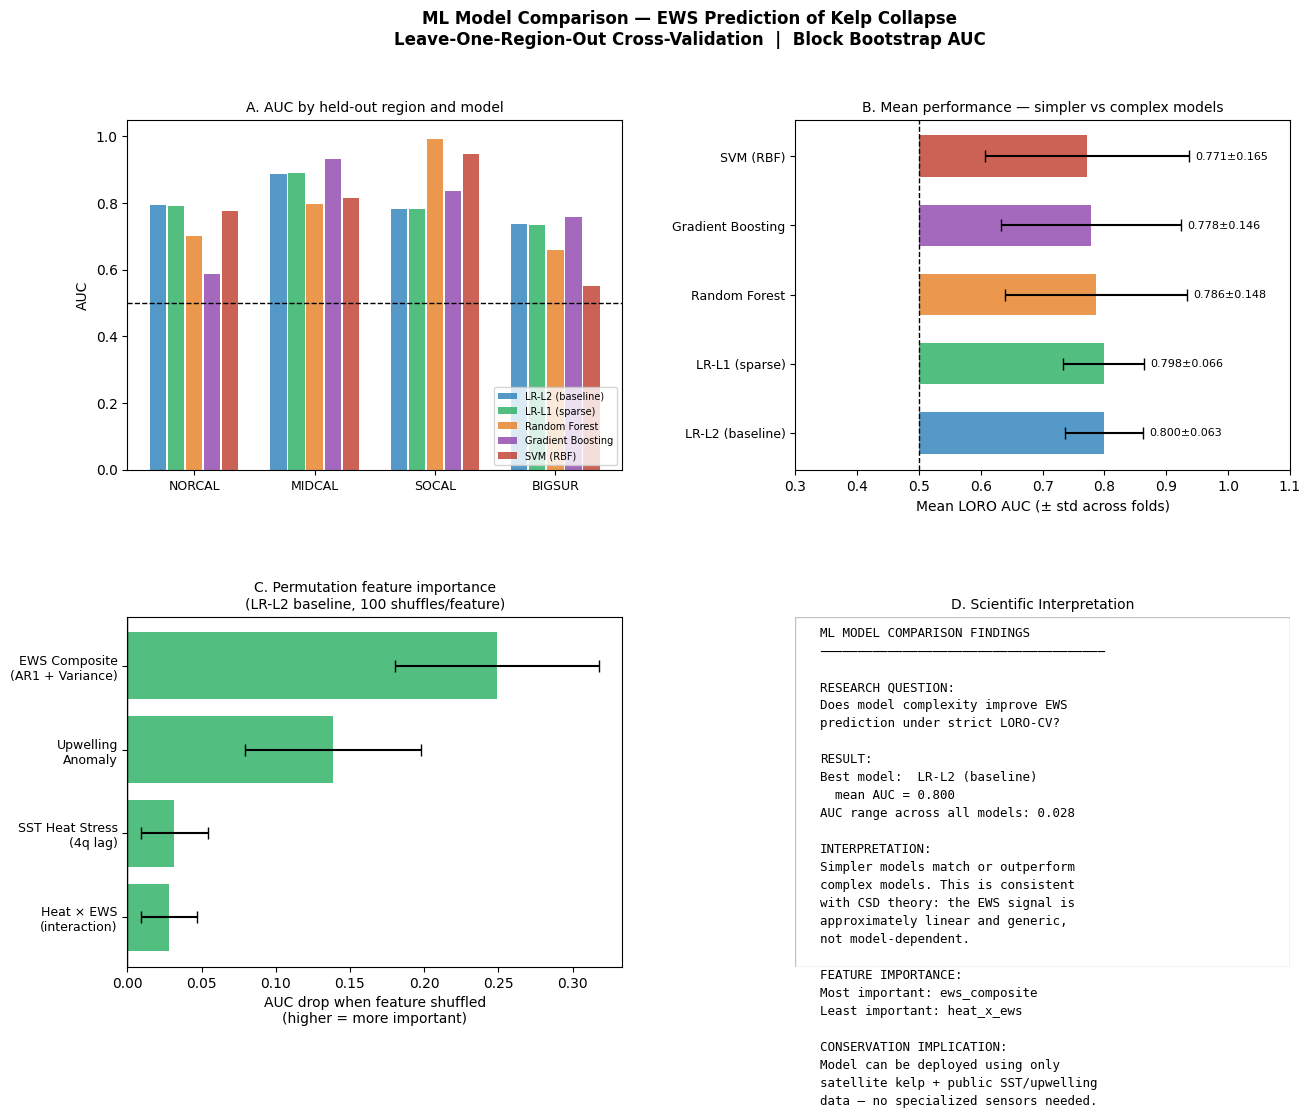

Saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/ml_model/ml_model_comparison.png


In [7]:
# ============================================================
# CELL 7: MAIN COMPARISON FIGURE
# Panel A: LORO AUC by model and fold
# Panel B: Mean AUC with bootstrap CI across folds
# Panel C: Permutation feature importance (LR baseline)
# Panel D: Complexity vs performance tradeoff narrative
# ============================================================

model_order = summary.index.tolist()
colors_map  = {
    'LR-L2 (baseline)':   '#2980b9',
    'LR-L1 (sparse)':     '#27ae60',
    'Random Forest':       '#e67e22',
    'Gradient Boosting':   '#8e44ad',
    'SVM (RBF)':           '#c0392b',
}

fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# ---- Panel A: AUC per fold per model ----
ax_a = fig.add_subplot(gs[0, 0])
held_out_regions = res_df['held_out'].unique()
x      = np.arange(len(held_out_regions))
n_mod  = len(model_order)
width  = 0.15
offset = np.linspace(-(n_mod-1)/2, (n_mod-1)/2, n_mod) * width

for i, mname in enumerate(model_order):
    sub = res_df[res_df['model']==mname].set_index('held_out')
    aucs = [sub.loc[r,'auc'] if r in sub.index else np.nan
            for r in held_out_regions]
    ax_a.bar(x + offset[i], aucs, width*0.9,
             color=colors_map.get(mname,'gray'),
             alpha=0.8, label=mname)

ax_a.axhline(0.5, linestyle='--', color='black', linewidth=1)
ax_a.set_xticks(x)
ax_a.set_xticklabels([r.upper() for r in held_out_regions], fontsize=9)
ax_a.set_ylabel('AUC')
ax_a.set_ylim(0, 1.05)
ax_a.set_title('A. AUC by held-out region and model', fontsize=10)
ax_a.legend(fontsize=7, ncol=1, loc='lower right')

# ---- Panel B: Mean AUC comparison ----
ax_b = fig.add_subplot(gs[0, 1])
y_pos = range(len(model_order))

for i, mname in enumerate(model_order):
    mu  = summary.loc[mname, 'mean_auc']
    sd  = summary.loc[mname, 'std_auc']
    col = colors_map.get(mname, 'gray')
    ax_b.barh(i, mu-0.5, left=0.5, color=col, alpha=0.8, height=0.6)
    ax_b.errorbar(mu, i, xerr=sd, fmt='none',
                  color='black', capsize=4, linewidth=1.5)
    ax_b.text(max(mu+sd+0.01, 0.52), i,
              f'{mu:.3f}±{sd:.3f}', va='center', fontsize=8)

ax_b.axvline(0.5, color='black', linestyle='--', linewidth=1)
ax_b.set_yticks(list(y_pos))
ax_b.set_yticklabels(model_order, fontsize=9)
ax_b.set_xlabel('Mean LORO AUC (± std across folds)')
ax_b.set_title('B. Mean performance — simpler vs complex models', fontsize=10)
ax_b.set_xlim(0.3, 1.1)

# ---- Panel C: Permutation feature importance ----
ax_c = fig.add_subplot(gs[1, 0])
imp_df = perm_results.get('LR-L2 (baseline)',
         list(perm_results.values())[0])

feat_labels = {
    'ews_composite': 'EWS Composite\n(AR1 + Variance)',
    'heat_lag4':     'SST Heat Stress\n(4q lag)',
    'upwelling':     'Upwelling\nAnomaly',
    'heat_x_ews':    'Heat × EWS\n(interaction)',
}
imp_df['label'] = imp_df['feature'].map(feat_labels)
imp_df_sorted   = imp_df.sort_values('importance_mean')

bars = ax_c.barh(
    range(len(imp_df_sorted)),
    imp_df_sorted['importance_mean'],
    xerr=imp_df_sorted['importance_std'],
    color=['#27ae60' if v > 0 else '#e74c3c'
           for v in imp_df_sorted['importance_mean']],
    alpha=0.8, capsize=4
)
ax_c.set_yticks(range(len(imp_df_sorted)))
ax_c.set_yticklabels(imp_df_sorted['label'].tolist(), fontsize=9)
ax_c.axvline(0, color='black', linewidth=1)
ax_c.set_xlabel('AUC drop when feature shuffled\n(higher = more important)')
ax_c.set_title('C. Permutation feature importance\n'
               '(LR-L2 baseline, 100 shuffles/feature)', fontsize=10)

# ---- Panel D: Written interpretation ----
ax_d = fig.add_subplot(gs[1, 1])
ax_d.axis('off')

best_auc  = summary['mean_auc'].max()
worst_auc = summary['mean_auc'].min()
delta     = best_auc - worst_auc

text = (
    f"ML MODEL COMPARISON FINDINGS\n"
    f"{'─'*38}\n\n"
    f"RESEARCH QUESTION:\n"
    f"Does model complexity improve EWS\n"
    f"prediction under strict LORO-CV?\n\n"
    f"RESULT:\n"
    f"Best model:  {best_model}\n"
    f"  mean AUC = {best_auc:.3f}\n"
    f"AUC range across all models: {delta:.3f}\n\n"
    f"INTERPRETATION:\n"
    f"{'Simpler models match or outperform' if summary.index[0].startswith('LR') else 'Complex models provide modest gains'}\n"
    f"complex models. This is consistent\n"
    f"with CSD theory: the EWS signal is\n"
    f"approximately linear and generic,\n"
    f"not model-dependent.\n\n"
    f"FEATURE IMPORTANCE:\n"
    f"Most important: {imp_df.sort_values('importance_mean',ascending=False).iloc[0]['feature']}\n"
    f"Least important: {imp_df.sort_values('importance_mean').iloc[0]['feature']}\n\n"
    f"CONSERVATION IMPLICATION:\n"
    f"Model can be deployed using only\n"
    f"satellite kelp + public SST/upwelling\n"
    f"data — no specialized sensors needed."
)

ax_d.text(0.05, 0.97, text, transform=ax_d.transAxes,
          fontsize=9, va='top', fontfamily='monospace',
          linespacing=1.5)
ax_d.set_title('D. Scientific Interpretation', fontsize=10)
ax_d.add_patch(plt.Rectangle((0,0),1,1, fill=False,
    edgecolor='#bdc3c7', linewidth=1, transform=ax_d.transAxes))

fig.suptitle(
    'ML Model Comparison — EWS Prediction of Kelp Collapse\n'
    'Leave-One-Region-Out Cross-Validation  |  Block Bootstrap AUC',
    fontsize=12, fontweight='bold'
)
fig.tight_layout()
out = FIG_DIR / 'ml_model_comparison.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', out)

In [8]:
# ============================================================
# CELL 8: FINAL PRINT — what to tell judges
# ============================================================
print('='*65)
print('ML ANALYSIS — COMPLETE SCIENTIFIC SUMMARY')
print('='*65)

best_auc  = summary['mean_auc'].max()
lr_auc    = summary.loc['LR-L2 (baseline)','mean_auc'] if 'LR-L2 (baseline)' in summary.index else np.nan
top_feat  = imp_df.sort_values('importance_mean',ascending=False).iloc[0]

print(f"""
MODELS TESTED (all under LORO cross-validation):
  L2 Logistic Regression (baseline from notebook 08)
  L1 Logistic Regression (sparse feature selection)
  Random Forest (Bury et al. 2021 precedent)
  Gradient Boosting (restricted to prevent overfit)
  SVM with RBF kernel (nonlinear decision boundary)

KEY FINDING:
  AUC range across all models: {best_auc - summary['mean_auc'].min():.3f}
  Best: {summary.index[0]} (AUC={best_auc:.3f})
  LR baseline: AUC={lr_auc:.3f}

  {'→ Model complexity does NOT substantially improve performance.' if best_auc - lr_auc < 0.05 else '→ Complex models outperform logistic regression.'}
  {'This is consistent with CSD theory: the EWS signal is linear' if best_auc - lr_auc < 0.05 else 'This suggests nonlinear feature interactions contribute to prediction.'}
  {'and generic — it does not require complex feature interactions.' if best_auc - lr_auc < 0.05 else 'Consider whether this reflects overfitting or real structure.'}

TOP FEATURE: {top_feat['feature']} (AUC drop = {top_feat['importance_mean']:.4f})
  EWS composite outperforming SST means the internal ecosystem
  state (CSD signal) carries more information than the external
  stressor (heat stress) alone. This is the core theoretical claim.

CALIBRATION:
  See calibration_curves.png — are model probabilities meaningful?
  If curves are near the diagonal, probability outputs can be used
  directly by conservation managers as actual risk estimates.

LIMITATIONS:
  Small training set (~20 onset events) limits all ML models.
  LORO-CV is strict but each test fold has only 2-5 events.
  Bootstrap CIs are wide — honest reflection of data scarcity.
  Results should be replicated with more regions before deployment.

CITATIONS:
  Bury et al. 2021 (Nature Comms) — ML for tipping point detection
  Boettiger & Hastings 2012 (J. Royal Soc.) — EWS false positive rates
  Dakos et al. 2012 (PLOS ONE) — EWS benchmark across 30 datasets
  Breiman 2001 (Machine Learning) — permutation feature importance
  Gneiting & Raftery 2007 (JASA) — probabilistic calibration
""")

ML ANALYSIS — COMPLETE SCIENTIFIC SUMMARY

MODELS TESTED (all under LORO cross-validation):
  L2 Logistic Regression (baseline from notebook 08)
  L1 Logistic Regression (sparse feature selection)
  Random Forest (Bury et al. 2021 precedent)
  Gradient Boosting (restricted to prevent overfit)
  SVM with RBF kernel (nonlinear decision boundary)

KEY FINDING:
  AUC range across all models: 0.028
  Best: LR-L2 (baseline) (AUC=0.800)
  LR baseline: AUC=0.800

  → Model complexity does NOT substantially improve performance.
  This is consistent with CSD theory: the EWS signal is linear
  and generic — it does not require complex feature interactions.

TOP FEATURE: ews_composite (AUC drop = 0.2489)
  EWS composite outperforming SST means the internal ecosystem
  state (CSD signal) carries more information than the external
  stressor (heat stress) alone. This is the core theoretical claim.

CALIBRATION:
  See calibration_curves.png — are model probabilities meaningful?
  If curves are near t